In [2]:
import torch
import torch.nn
import torchvision.transforms as T
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
import json

In [7]:
from transformers import ConvNextForImageClassification
HFmodel = ConvNextForImageClassification.from_pretrained("facebook/convnext-base-384-22k-1k", cache_dir="./cache").eval()

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/354M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/344 [00:00<?, ?it/s]

In [12]:
!wget https://upload.wikimedia.org/wikipedia/commons/thumb/0/0f/Grosser_Panda.JPG/960px-Grosser_Panda.JPG

--2026-03-05 16:16:35--  https://upload.wikimedia.org/wikipedia/commons/thumb/0/0f/Grosser_Panda.JPG/960px-Grosser_Panda.JPG
Resolving upload.wikimedia.org (upload.wikimedia.org)... 185.15.59.240, 2a02:ec80:300:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|185.15.59.240|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 177193 (173K) [image/jpeg]
Saving to: ‘960px-Grosser_Panda.JPG’

960px-Grosser_Panda 100%[===================>] 173,04K  --.-KB/s    in 0,1s    

2026-03-05 16:16:35 (1,50 MB/s) - ‘960px-Grosser_Panda.JPG’ saved [177193/177193]



In [13]:
image_path = "./960px-Grosser_Panda.JPG"
image = Image.open(image_path)

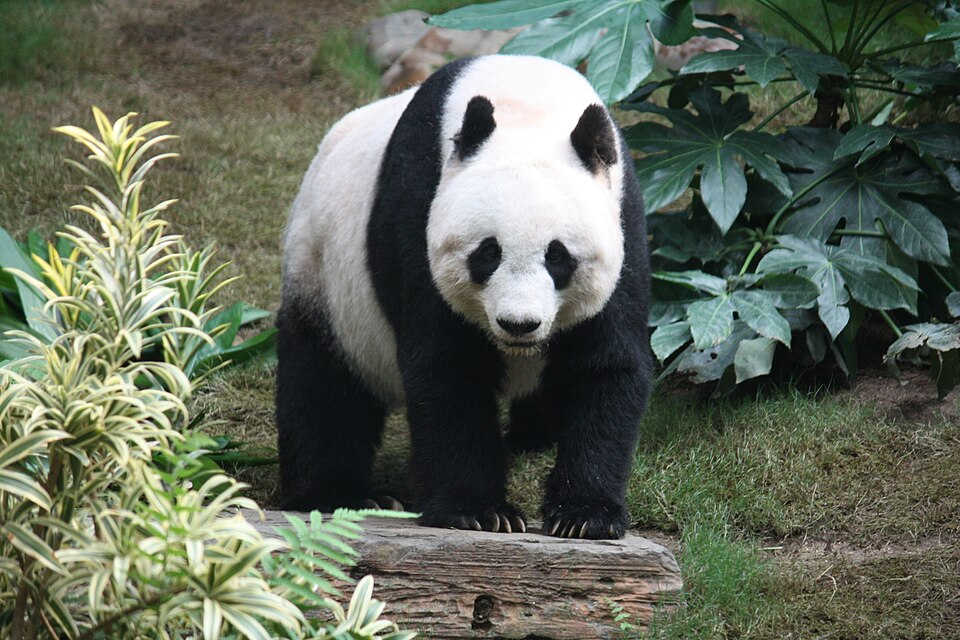

In [14]:
image

In [15]:
torch_original = T.ToTensor()(image)
torch_original = T.Resize([480,640])(torch_original)

In [16]:
torch_original.shape

torch.Size([3, 480, 640])

In [25]:
torch_original.unsqueeze(0).shape

torch.Size([1, 3, 480, 640])

In [21]:
res = HFmodel(torch_original.unsqueeze(0)).logits
base_prediction = torch.argmax(res).item()

In [30]:
torch.max(res)

tensor(6.5073, grad_fn=<MaxBackward1>)

In [22]:
base_prediction

388

In [23]:
!wget https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json

--2026-03-05 16:20:04--  https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json
Resolving s3.amazonaws.com (s3.amazonaws.com)... 52.217.69.230, 52.217.235.184, 54.231.230.88, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|52.217.69.230|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 35363 (35K) [application/octet-stream]
Saving to: ‘imagenet_class_index.json’

imagenet_class_inde 100%[===================>]  34,53K  --.-KB/s    in 0,1s    

2026-03-05 16:20:04 (282 KB/s) - ‘imagenet_class_index.json’ saved [35363/35363]



In [26]:
dataset_classes = json.load(open("imagenet_class_index.json"))

In [28]:
dataset_classes['388']

['n02510455', 'giant_panda']

In [29]:
dataset_classes['368']

['n02483362', 'gibbon']

In [33]:
ground_truth_id = 388
target_id = 368

In [34]:
def normalize(x, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    n_channels = len(mean)
    mean = torch.tensor(mean).reshape(1, n_channels, 1, 1)
    std = torch.tensor(std).reshape(1, n_channels, 1, 1)
    return (x - mean)/std
    

In [40]:
device="cpu"

In [41]:
import torch
import torch.nn as nn

In [43]:
images = torch_original.unsqueeze(0)
labels = torch.tensor([ground_truth_id])

images = images.clone().detach().to(device)
labels = labels.clone().detach().to(device)

target_labels = torch.tensor([target_id])
target = torch.zeros(1000)
target[target_id] = 1
target = target.reshape(1,1000)

loss = nn.CrossEntropyLoss()
adv_images = images.clone().detach()

eps = 4/255
alpha = 1/255
steps = 4
# Starting at a uniformly random point
adv_images = adv_images + torch.empty_like(adv_images).uniform_(
    -eps, eps
)
adv_images = torch.clamp(adv_images, min=0, max=1).detach()

for _ in range(steps):
    adv_images.requires_grad = True
    x = normalize(adv_images)
    outputs = HFmodel(x).logits
    print(target.shape)
    print(outputs.shape)

    cost = -loss(outputs, target)

    grad = torch.autograd.grad(
        cost, adv_images, retain_graph=False, create_graph=False
    )[0]

    adv_images = adv_images.detach() + alpha * grad.sign()
    delta = torch.clamp(adv_images - images, min=-eps, max=eps)
    adv_images = torch.clamp(images + delta, min=0, max=1).detach()

torch.Size([1, 1000])
torch.Size([1, 1000])
torch.Size([1, 1000])
torch.Size([1, 1000])
torch.Size([1, 1000])
torch.Size([1, 1000])
torch.Size([1, 1000])
torch.Size([1, 1000])


In [45]:
logits = HFmodel(adv_images).logits
prediction = torch.argmax(logits).item()
message = "CORRECT! Model was pwnd." if target_id==prediction else "Wrong!"
print(f"{message} target:{target_id}, prediction:{prediction}, ground_truth_id was:{ground_truth_id}")

CORRECT! Model was pwnd. target:368, prediction:368, ground_truth_id was:388


Text(0.5, 1.0, 'Class: Panda')

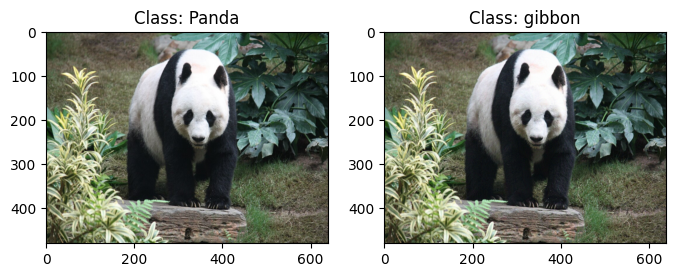

In [49]:
fig, axe = plt.subplots(1,2, figsize = (8,6))

crafted_image = adv_images[0].detach().permute(1,2,0).cpu().numpy()
original_image = torch_original.detach().permute(1,2,0).cpu().numpy()
axe[1].imshow(crafted_image)
crafted_class_name = dataset_classes[str(prediction)][1]
axe[1].set_title(f"Class: {crafted_class_name}")
axe[0].imshow(original_image)
axe[0].set_title(f"Class: Panda")